In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pylab as plt
import networkx as nx
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from sklearn.manifold import MDS

import os
import modules
import types
from matplotlib import font_manager

In [2]:
from modules import geometry
from modules import metrics
from modules import visualization as vis
from modules.projector import MDSTorusProjector
from modules import apsp_distance_matrix
import sys
sys.path.append('../')
from data.utils import get_path

In [3]:
# quick helper to compute stress --> needed?
def torus_stress(X, D, proj):
    geod = geometry.make_torus_geod(proj.alpha_, proj.r0_, proj.r1_, proj.theta_)
    return metrics.geodesic_stress(X, D, geod)

In [4]:
# load data
data_path = os.path.join(get_path(), "grid_cells")

a = np.load(os.path.join(data_path, "grid_cells_4800.npz"))
data = a['data']
spikes = a['spikes']
xx = a['xx']
yy = a['yy']

cell_ids = [
    5, 39,
    75, 109, 115] # cells with clearly structured firing pattern

In [5]:
# register the bundled Arial faces first, otherwise the style's "font.sans-serif: Arial"
# silently falls back to DejaVu. addfont works per session, no font cache rebuild, and a
# missing arial_font directory just yields an empty list rather than an error.
modules_dir = os.path.dirname(modules.__file__)
arial_dir = os.path.join(os.path.dirname(modules_dir), "arial_font")
for ttf in font_manager.findSystemFonts(fontpaths=[arial_dir]):
    font_manager.fontManager.addfont(ttf)

plt.style.use(os.path.join(modules_dir, "style.mplstyle"))
print("Arial registered:", "Arial" in {f.name for f in font_manager.fontManager.ttflist})

Arial registered: True


In [6]:
SEEDS = [0, 1, 2]     # every embedding is fit once per seed; the figure shows SEEDS[0]
CMAP = "viridis"      # style.mplstyle sets image.cmap to tab10, so pass a cmap explicitly

def mean_std(values, fmt=".4f"):
    """format an iterable of numbers as 'mean ± std'"""
    v = np.asarray(list(values), dtype=float)
    return f"{v.mean():{fmt}} ± {v.std():{fmt}}"

In [7]:
# cache for the expensive part of this section: nine fits plus nine stress evaluations.
# flat arrays in one npz rather than a pickle, so the file still loads after the modules
# or MDSTorusProjector change, which is exactly the situation that makes you want it.

CACHE = os.path.join(data_path, "grid_cells_main_cache.npz")
GEOM_ATTRS = ("alpha_", "r0_", "r1_", "theta_")   # all that plotting and torus_stress read


def save_fits(path, seeds, embeddings, projectors, stresses):
    """
    embeddings and projectors are {name: {seed: value}}, stresses is {name: [per seed]}.

    Only GEOM_ATTRS is kept from each projector, alongside its embedding, which is the
    same array fit_transform returned. Nothing else is needed to plot a fit or score it.
    """
    blobs = {"seeds": np.asarray(seeds)}
    for name, Xs in embeddings.items():
        blobs[f"X_{name}"] = np.stack([Xs[s] for s in seeds])
    for name, projs in projectors.items():
        blobs[f"geom_{name}"] = np.array([[getattr(projs[s], a) for a in GEOM_ATTRS]
                                          for s in seeds], dtype=float)
    for name, values in stresses.items():
        blobs[f"stress_{name}"] = np.asarray(values, dtype=float)
    np.savez_compressed(path, **blobs)
    print(f"wrote {path} ({os.path.getsize(path) / 1e6:.2f} MB): {sorted(blobs)}")


def load_fits(path=CACHE):
    """
    Inverse of save_fits, returning (seeds, embeddings, projectors, stresses).

    The projectors come back as SimpleNamespaces, not MDSTorusProjector instances. They
    carry torus_embedding_ and GEOM_ATTRS, which is everything torus_stress and the
    plotting functions touch, but they cannot be re-fit.
    """
    c = np.load(path)
    seeds = [int(s) for s in c["seeds"]]
    embeddings, projectors, stresses = {}, {}, {}
    for key in c.files:
        arr = c[key]                    # NpzFile decompresses on every lookup, so hoist it
        if key.startswith("X_"):
            embeddings[key[2:]] = {s: arr[i] for i, s in enumerate(seeds)}
        elif key.startswith("stress_"):
            stresses[key[7:]] = list(arr)
    for key in c.files:
        if not key.startswith("geom_"):
            continue
        name, geom = key[5:], c[key]
        projectors[name] = {
            s: types.SimpleNamespace(torus_embedding_=embeddings[name][s],
                                     **dict(zip(GEOM_ATTRS, map(float, geom[i]))))
            for i, s in enumerate(seeds)}
    return seeds, embeddings, projectors, stresses

In [8]:
k = 15
A_geo = kneighbors_graph(data, n_neighbors=k, mode='distance', include_self=False)
A_geo = A_geo.maximum(A_geo.T)  # symmetrize, weights = euclidean edge lengths
G_geo = nx.from_scipy_sparse_array(A_geo)

D_geo, _ = apsp_distance_matrix(G_geo, method="scipy")

assert not np.isinf(D_geo).any(), "kNN graph is disconnected, increase k"
print(D_geo.shape, f"max geodesic: {D_geo.max():.0f}")

#D_geo /= D_geo.max()

(4800, 4800) max geodesic: 27


In [ ]:
Xs_eucl, Xs_sq, Xs_para = {}, {}, {}
projs_sq, projs_para = {}, {}

for seed in SEEDS:
     # default learn_mode='alpha': square torus (r0 = r1 = 1) with a learned overall scale
    projs_sq[seed] = MDSTorusProjector()
    Xs_sq[seed] = projs_sq[seed].fit_transform(D_geo, seed=seed)

    # init theta at 80 deg, deliberately away from 60, so recovering ~60 is not baked in
    projs_para[seed] = MDSTorusProjector()
    Xs_para[seed] = projs_para[seed].fit_transform(D_geo, learn_mode='parallelogram',
                                                   theta=80.0, seed=seed)

    print(f"seed {seed}: parallelogram theta = {np.degrees(projs_para[seed].theta_):.2f} deg, "
          f"r1/r0 = {projs_para[seed].r1_ / projs_para[seed].r0_:.3f}")

    Xs_eucl[seed] = MDS(metric="precomputed", n_init=1, random_state=seed,
                        normalized_stress=False).fit_transform(D_geo)

    print(f"seed {seed} done")

In [84]:
# stress, reported here rather than in the figure. geodesic_stress is a Python double loop
# over all pairs
s_eucl = [metrics.geodesic_stress(Xs_eucl[s], D_geo, geometry.euc_distance) for s in SEEDS]
s_sq = [torus_stress(Xs_sq[s], D_geo, projs_sq[s]) for s in SEEDS]
s_para = [torus_stress(Xs_para[s], D_geo, projs_para[s]) for s in SEEDS]
thetas = [np.degrees(np.pi/2- np.abs(projs_para[s].theta_ - (np.pi/2))) for s in SEEDS] # consider both 60 degrees and 120 degrees as 60 degrees
thetas_rad = [(np.pi/2- np.abs(projs_para[s].theta_ - (np.pi/2)))/np.pi for s in SEEDS]

print(f"kNN geodesic distances, n={len(SEEDS)} runs each")
print(f"  Euclidean MDS        stress {mean_std(s_eucl)}")
print(f"  Square torus         stress {mean_std(s_sq)}")
print(f"  Parallelogram torus  stress {mean_std(s_para)},  theta {mean_std(thetas, '.3f')} deg, theta_rad {mean_std(thetas_rad, '.3f')} pi")

kNN geodesic distances, n=3 runs each
  Euclidean MDS        stress 0.2968 ± 0.0058
  Square torus         stress 0.2345 ± 0.0020
  Parallelogram torus  stress 0.1549 ± 0.0000,  theta 61.977 ± 0.528 deg, theta_rad 0.344 ± 0.003 pi


In [93]:
# run this once now, while the fits are still in memory. re-run it whenever the fits or
# the stress numbers change.
save_fits(CACHE, SEEDS,
          {"eucl": Xs_eucl, "sq": Xs_sq, "para": Xs_para},
          {"sq": projs_sq, "para": projs_para},
          {"eucl": s_eucl, "sq": s_sq, "para": s_para,
           "theta": thetas, "theta_rad": thetas_rad})

wrote /gpfs01/berens/user/sdamrich/data/graph_torus/grid_cells/grid_cells_main_cache.npz (0.66 MB): ['X_eucl', 'X_para', 'X_sq', 'geom_para', 'geom_sq', 'seeds', 'stress_eucl', 'stress_para', 'stress_sq', 'stress_theta', 'stress_theta_rad']


In [9]:
# restore the cached fits instead of refitting. after a kernel restart, run the imports,
# torus_stress, the data load, the style, the xx/yy, config and cache cells and the kNN
# cell (all seconds), then skip the fit and stress cells and run this one.
SEEDS, _emb, _proj, _stress = load_fits(CACHE)
Xs_eucl, Xs_sq, Xs_para = _emb["eucl"], _emb["sq"], _emb["para"]
projs_sq, projs_para = _proj["sq"], _proj["para"]
s_eucl, s_sq, s_para = _stress["eucl"], _stress["sq"], _stress["para"]
thetas, thetas_rad = _stress["theta"], _stress["theta_rad"]

print(f"restored seeds {SEEDS} from {CACHE}")
print(f"  Euclidean MDS        stress {mean_std(s_eucl)}")
print(f"  Square torus         stress {mean_std(s_sq)}")
print(f"  Parallelogram torus  stress {mean_std(s_para)},  theta {mean_std(thetas, '.3f')} deg, theta_rad {mean_std(thetas_rad, '.3f')} pi")

restored seeds [0, 1, 2] from /gpfs01/berens/user/sdamrich/data/graph_torus/grid_cells/grid_cells_main_cache.npz
  Euclidean MDS        stress 0.2968 ± 0.0058
  Square torus         stress 0.2345 ± 0.0020
  Parallelogram torus  stress 0.1549 ± 0.0000,  theta 61.977 ± 0.528 deg, theta_rad 0.344 ± 0.003 pi


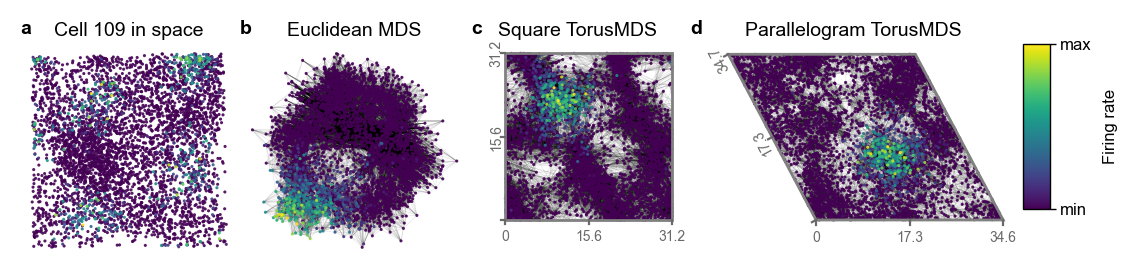

In [12]:
# one subfigure per panel, so every panel letter lands at the same height (the axes boxes
# do not: equal aspect shrinks each box to its own shape). widths follow the drawn aspect
# of each panel, so constrained_layout letterboxes none of them. one extra subfigure holds
# the colorbar. the panel height then follows from the width, and figsize's height only
# controls how much whitespace is left above and below the row.
seed = SEEDS[2]
CELL = 109        # every panel is coloured by this cell's firing rate   (115, 2), (109, 2) are good combinations

rate = spikes[:, CELL]
order = np.argsort(rate)          # high firing rates drawn on top
vmax = float(rate.max())
s = 10

space = np.column_stack([xx, yy])

def scatter_aspect(P):
    """width / height of a plain equal-aspect scatter panel"""
    span = P.max(axis=0) - P.min(axis=0)
    return span[0] / span[1]

# (letter, title, torus or None, coordinates or None, graph or None). the kNN graph goes
# into b-d, the three layouts of D_geo; panel a is physical space, where it has no meaning
panels = [("a", f"Cell {CELL} in space", None, space, None),
          ("b", "Euclidean MDS", None, Xs_eucl[seed], G_geo),
          ("c", "Square TorusMDS", projs_sq[seed], None, G_geo),
          ("d", "Parallelogram TorusMDS", projs_para[seed], None, G_geo)]

widths = [scatter_aspect(P) if t is None else vis.torus_panel_aspect(t)
          for _, _, t, P, _ in panels]
# colorbar column: bar, tick labels and axis label. taken as a share of the panel row
# rather than a fixed number, so it keeps its width in inches if the panel aspects change.
# too narrow and constrained_layout gives up ("axes sizes collapsed to zero") and silently
# falls back to the default subplot grid, which leaves gaps between the panels.
widths.append(0.10 * sum(widths))

fig = plt.figure(figsize=(5.5, 1.25), layout="constrained")
fig.get_layout_engine().set(w_pad=0.01, h_pad=0.01, wspace=0.01, hspace=0.0)
subfigs = fig.subfigures(1, len(widths), width_ratios=widths, wspace=0.01)

for (letter, title, torus, P, graph), sfig in zip(panels, subfigs):
    sfig.text(0.0, 1.0, letter, ha="left", va="top", fontweight="bold", fontsize=7)
    ax = sfig.subplots()
    # edge_alpha and edge_lw are tuned for G_geo's ~40k edges on a ~1 inch panel: raise
    # them together for a sparser graph, lower them before the mesh buries the colours
    shared = dict(ax=ax, G=graph, order=order, colors=rate, cmap=CMAP,
                  vmin=0, vmax=vmax,   # pin the range so one colorbar describes every panel
                  s=s, node_lw=0,      # the default edge width would double these markers
                  edge_alpha=0.12, edge_lw=0.2,
                  rasterized=True)     # 4800 points and ~40k edges a panel: keep them out
    if torus is None:                  # of the vector layer
        vis.plot_embedding(P, **shared)   # flat layout: straight edges, no wrapping
        ax.axis("off")
    else:
        vis.plot_embedding_with_torus_edges(
            torus=torus,
            n_ticks=3,                 # 5 ticks at fontsize 8 collide on ~1 inch wide panels
            tick_fontsize=5,           # deliberately below the 6pt body text of style.mplstyle
            **shared)
    ax.set_title(title)

# shared firing-rate colorbar in its own axes on the right. the blank title reserves the
# same header line as the panels, so the bar lines up with the panel row, and the empty
# bottom row of the gridspec lifts it clear of the figure floor.
cb_lift = 0.3
cax = subfigs[-1].add_subplot(subfigs[-1].add_gridspec(2, 1, height_ratios=[1, cb_lift])[0])
cax.set_title(" ")
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(0, vmax), cmap=CMAP), cax=cax)
cbar.set_label("Firing rate")
cbar.set_ticks([0, vmax])
cbar.ax.set_yticklabels(["min", f"max"])

# rasterized artists take their resolution from the savefig dpi, not from figure.dpi
fig.savefig("grid_cells_main.pdf", dpi=400)